count    1000.000000
mean     2233.323000
std        75.715781
min      1974.000000
25%      2180.000000
50%      2232.500000
75%      2284.000000
max      2481.000000
dtype: float64
Model stabilizes at run 280 with total bites: 2226


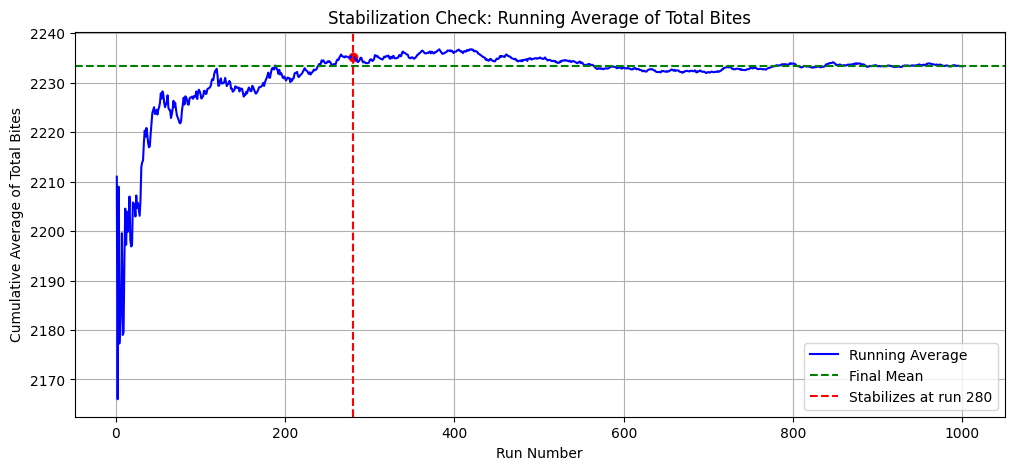

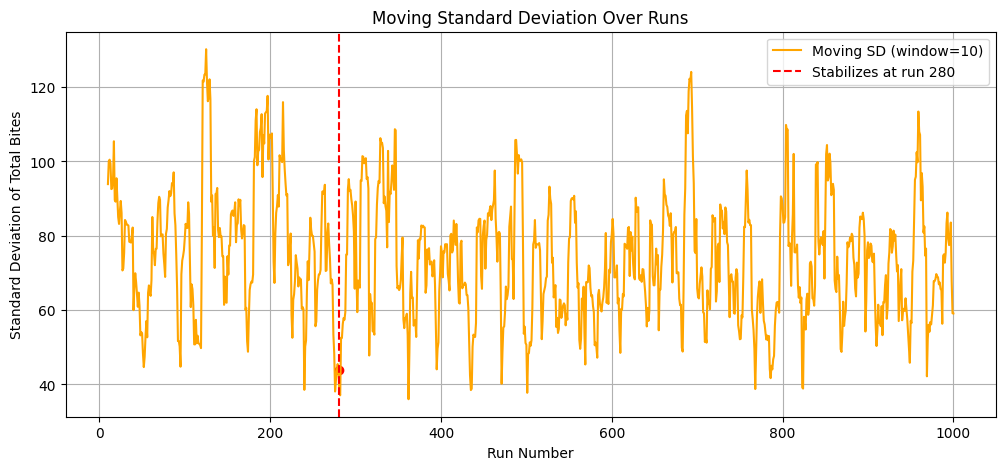

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the CSV file
file_path = r"C:\Users\arman\OneDrive - University of Twente\assignment_spatio\data\behaviour_space\stabalisation.csv"
df = pd.read_csv(file_path, skiprows=10)  # keep this to skip metadata

# Extracting bite counts only (skipping tick columns)
bite_counts = pd.Series([int(float(df.columns[i])) for i in range(2, len(df.columns), 2)])

print(bite_counts.describe())

# Creating DataFrame for analysis
data = pd.DataFrame({
    'Run': range(1, len(bite_counts) + 1),
    'Total_Bites': bite_counts
})

# Computing running average (cumulative mean)
data['Running_Avg'] = data['Total_Bites'].expanding().mean()

# Computing moving standard deviation with a window of 10
window_size = 10
data['Moving_SD'] = data['Total_Bites'].rolling(window=window_size).std()

# Defining stabilization threshold and consecutive run requirement
stabilization_threshold = 46 # update this line according to the printed std
consecutive_runs = 5

# Finding stabilization run
stabilization_run = None
for i in range(window_size + consecutive_runs - 1, len(data)):
    if (data['Moving_SD'].iloc[i-consecutive_runs+1:i+1] < stabilization_threshold).all():
        stabilization_run = data['Run'].iloc[i]
        stabilization_bite_count = data['Total_Bites'].iloc[i]
        break

# Output stabilization result
if stabilization_run:
    print(f"Model stabilizes at run {stabilization_run} with total bites: {stabilization_bite_count}")
else:
    print("Model did not stabilize within the given runs and threshold.")

# Plotting Running Average
plt.figure(figsize=(12, 5))
plt.plot(data['Run'], data['Running_Avg'], label='Running Average', color='blue')
plt.axhline(y=data['Running_Avg'].iloc[-1], color='green', linestyle='--', label='Final Mean')

# Marking stabilization point on plot if found
if stabilization_run:
    plt.axvline(x=stabilization_run, color='red', linestyle='--', label=f'Stabilizes at run {stabilization_run}')
    plt.scatter(stabilization_run, data['Running_Avg'].iloc[stabilization_run-1], color='red')

plt.xlabel('Run Number')
plt.ylabel('Cumulative Average of Total Bites')
plt.title('Stabilization Check: Running Average of Total Bites')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Moving Standard Deviation
plt.figure(figsize=(12, 5))
plt.plot(data['Run'], data['Moving_SD'], label=f'Moving SD (window={window_size})', color='orange')

# Marking stabilization point on plot if found
if stabilization_run:
    plt.axvline(x=stabilization_run, color='red', linestyle='--', label=f'Stabilizes at run {stabilization_run}')
    plt.scatter(stabilization_run, data['Moving_SD'].iloc[stabilization_run-1], color='red')

plt.xlabel('Run Number')
plt.ylabel('Standard Deviation of Total Bites')
plt.title('Moving Standard Deviation Over Runs')
plt.legend()
plt.grid(True)
plt.show()